# Homework 11 — Evaluation & Risk Communication

I quantify uncertainty with a bootstrap confidence interval, compare three "what-if" scenarios
(mean vs median imputation vs dropping missing rows), check stability across subgroups, and close with
a plain-language stakeholder summary. The reusable helpers live in `src/evaluation.py` and are imported
below.

The dataset has **fat-tailed (t-distributed) errors** and **5% missingness** in the feature, so it is
built to expose the exact places where Gaussian assumptions and naive metric reads go wrong.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path
import sys

HOMEWORK_DIR = Path.cwd()
ROOT = HOMEWORK_DIR
SRC_DIR = ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Homework directory:', HOMEWORK_DIR)
print('Source directory:', SRC_DIR)

CHECKS = [
    ('src/evaluation.py', 'NEEDED', 'YOU write this in the homework - the import fails until you do'),
]

print(f'Looking in: {ROOT}\n')
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == 'NEEDED':
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<30}  {note}")

if missing:
    print(f'\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}')
else:
    print('\nAll needed files present.')

Homework directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework11
Source directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework11/src
Looking in: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework11

  [OK ]  NEEDED    src/evaluation.py               YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(111)
plt.rcParams['figure.figsize'] = (8, 5)

# --- Load or generate the data (auto-created CSV, saved under data/raw/) ---
raw_dir = Path('data/raw')
raw_dir.mkdir(parents=True, exist_ok=True)
csv_path = raw_dir / 'data_stage11_eval_risk.csv'

if csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=['date'])
else:
    n = 180
    dates = pd.date_range('2022-06-01', periods=n, freq='D')
    seg = np.random.choice(['A', 'B', 'C'], size=n, p=[0.5, 0.3, 0.2])
    x = np.linspace(0, 9, n) + np.random.normal(0, 0.7, n)
    y = 2.1 * x + 0.8 + np.random.standard_t(df=3, size=n) * 1.1   # fat-tailed errors
    x[np.random.choice(np.arange(n), size=round(0.05 * n), replace=False)] = np.nan
    df = pd.DataFrame({'date': dates, 'segment': seg, 'x_feature': x, 'y_target': y})
    df.to_csv(csv_path, index=False)
    print(f'Generated and saved synthetic data to {csv_path}')

print('shape:', df.shape, '| missing x_feature:', int(df['x_feature'].isna().sum()))
df.head()

Generated and saved synthetic data to data/raw/data_stage11_eval_risk.csv
shape: (180, 4) | missing x_feature: 9


,date,segment,x_feature,y_target
0,2022-06-01,B,0.547868,2.107524
1,2022-06-02,A,0.974480,2.209111
2,2022-06-03,A,-0.012991,0.867315
3,2022-06-04,B,-1.012503,-1.741932
4,2022-06-05,A,0.642399,1.615007


## Helper functions — `src/evaluation.py`

Imputation, OLS fit, MAE/RMSE, and three bootstrap routines are packaged in `src/evaluation.py` and
imported here. *(Deviation from the starter: its hand-rolled `SimpleLinReg` is replaced with
`sklearn.linear_model.LinearRegression` — same least-squares result, standard implementation.)*

In [4]:
from src.evaluation import (
    mean_impute, median_impute, fit_ols, predict, mae, rmse,
    bootstrap_metric, bootstrap_predictions, bootstrap_scenario_mae,
)
print('imported evaluation helpers from src/evaluation.py')

imported evaluation helpers from src/evaluation.py


## Baseline fit

Impute the missing `x_feature` with the mean, fit `y ~ 1 + x`, and report MAE. The true relationship is
`y = 2.1*x + 0.8 + t(3)*1.1`, so a slope near 2.1 and intercept near 0.8 means the model recovered the
signal.

In [5]:
X_raw = df['x_feature'].values
y = df['y_target'].values
X_base = mean_impute(X_raw)

model = fit_ols(X_base, y)
y_hat = predict(model, X_base)
df['x_imputed'] = X_base

base_mae = mae(y, y_hat)
print(f'Baseline MAE       = {base_mae:.4f}')
print(f'Fitted slope       = {model.coef_[0]:.4f}   (true 2.1)')
print(f'Fitted intercept   = {model.intercept_:.4f}   (true 0.8)')

Baseline MAE       = 1.2783
Fitted slope       = 2.1302   (true 2.1)
Fitted intercept   = 0.7115   (true 0.8)


## Gaussian-based vs Bootstrap-based CI

Two ways to put an interval around the fitted line. The **Gaussian** band uses the residual standard
error (`sigma/sqrt(n)`) and so assumes normal errors and a constant band. The **bootstrap** band
resamples rows, refits, and takes percentiles — it lets the data's actual (fat-tailed) shape show
through, which is why it fans out and sits wider than the Gaussian band.

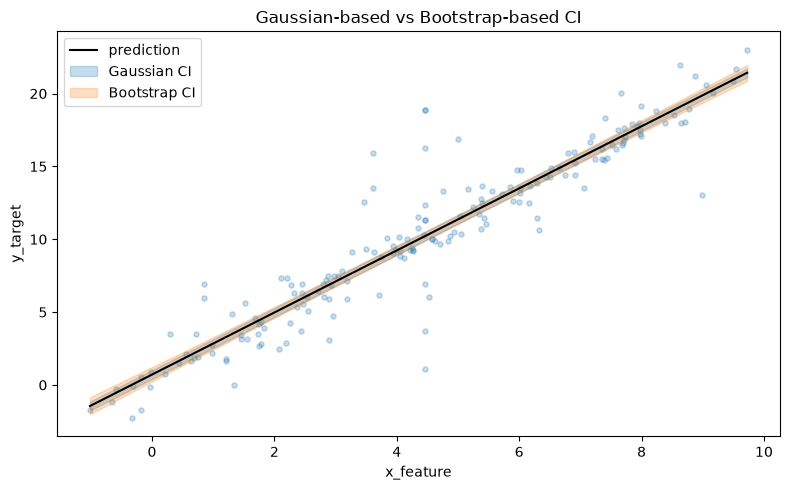

In [6]:
resid = y - y_hat
sigma_hat = np.std(resid, ddof=1)
n = len(y)
se_mean = sigma_hat / np.sqrt(n)

x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120)
pred_line = predict(model, x_grid)
gauss_lo = pred_line - 1.96 * se_mean
gauss_hi = pred_line + 1.96 * se_mean

m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_base, y, alpha=0.25, s=14)
ax.plot(x_grid, pred_line, color='black', lw=1.5, label='prediction')
ax.fill_between(x_grid, gauss_lo, gauss_hi, alpha=0.25, color='tab:blue', label='Gaussian CI')
ax.fill_between(x_grid, lo_boot, hi_boot, alpha=0.25, color='tab:orange', label='Bootstrap CI')
ax.set_xlabel('x_feature')
ax.set_ylabel('y_target')
ax.set_title('Gaussian-based vs Bootstrap-based CI')
ax.legend()
fig.tight_layout()
plt.show()

## Scenario sensitivity — three assumptions, side by side

Three treatments of the 5% missingness: **mean imputation**, **median imputation**, and **dropping** the
missing rows. I report the fitted slope/intercept and MAE for each, and add a bootstrap CI on MAE so the
comparison carries its own uncertainty. *(The starter's version is extended with the bootstrap error bars
and a fair shared-rows check.)*

In [7]:
def drop_missing(X, y):
    m = ~np.isnan(X)
    return X[m], y[m]

scenarios = {
    'mean_impute':   lambda X, y: (mean_impute(X), y),
    'median_impute': lambda X, y: (median_impute(X), y),
    'drop_missing':  drop_missing,
}

rows = []
for name, proc in scenarios.items():
    Xs, ys = proc(X_raw, y)
    m = fit_ols(Xs, ys)
    yh = predict(m, Xs)
    rows.append({'scenario': name, 'n_eval': len(ys),
                 'mae': mae(ys, yh), 'slope': float(m.coef_[0]), 'intercept': float(m.intercept_)})
sens = pd.DataFrame(rows)

Path('data/processed').mkdir(parents=True, exist_ok=True)
sens.to_csv('data/processed/scenario_results.csv', index=False)
sens.round(4)

,scenario,n_eval,mae,slope,intercept
0,mean_impute,180,1.2783,2.1302,0.7115
1,median_impute,180,1.2840,2.1293,0.7271
2,drop_missing,171,1.0646,2.1302,0.6592


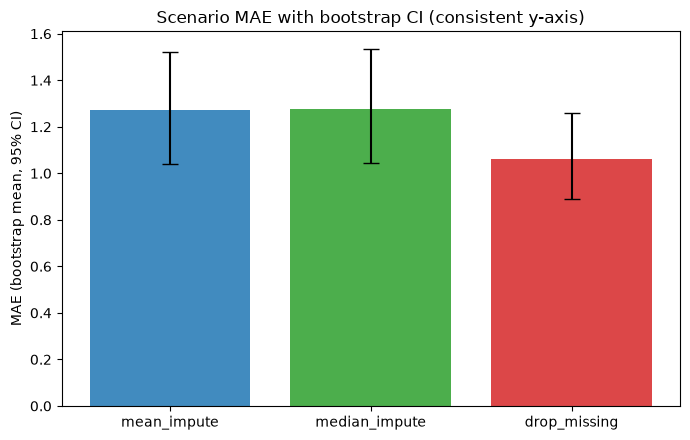

In [8]:
# Bootstrap the MAE of each scenario so the bars carry a 95% CI.
cis = {name: bootstrap_scenario_mae(X_raw, y, proc, n_boot=600)
       for name, proc in scenarios.items()}

fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(scenarios.keys())
means = [cis[k]['mae_mean'] for k in names]
errs = [[means[i] - cis[k]['mae_lo'] for i, k in enumerate(names)],
        [cis[k]['mae_hi'] - means[i] for i, k in enumerate(names)]]
ax.bar(names, means, yerr=errs, capsize=6, alpha=0.85, color=['tab:blue', 'tab:green', 'tab:red'])
ax.set_ylabel('MAE (bootstrap mean, 95% CI)')
ax.set_title('Scenario MAE with bootstrap CI (consistent y-axis)')
fig.tight_layout()
plt.show()

In [9]:
# Fair comparison: score mean/median imputation on the SAME non-missing rows that
# 'drop' uses. This isolates the effect of the imputation choice on the FIT.
m_mask = ~np.isnan(X_raw)
fair = {}
for name, proc in scenarios.items():
    Xs, ys = proc(X_raw, y)
    m = fit_ols(Xs, ys)
    fair[name] = mae(y[m_mask], predict(m, X_raw[m_mask]))   # score only non-missing rows
print('MAE on the shared', int(m_mask.sum()), 'non-missing rows:')
for k, v in fair.items():
    print(f'  {k:14s} {v:.4f}')

MAE on the shared 171 non-missing rows:
  mean_impute    1.0726
  median_impute  1.0747
  drop_missing   1.0646


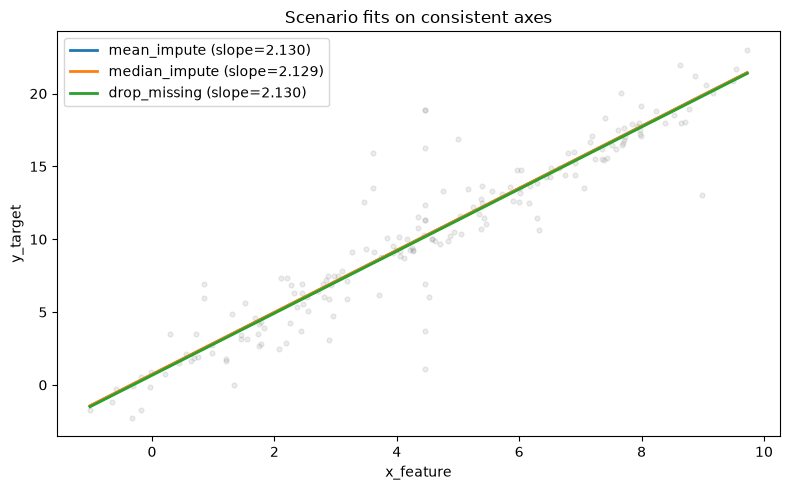

In [10]:
# Fit lines on one set of axes so the slopes are directly comparable.
fig, ax = plt.subplots(figsize=(8, 5))
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150)
for name, proc in scenarios.items():
    Xs, ys = proc(X_raw, y)
    m = fit_ols(Xs, ys)
    ax.plot(xg, predict(m, xg), lw=2, label=f'{name} (slope={m.coef_[0]:.3f})')
ax.scatter(X_base, y, alpha=0.15, s=12, color='grey')
ax.set_xlabel('x_feature')
ax.set_ylabel('y_target')
ax.set_title('Scenario fits on consistent axes')
ax.legend()
fig.tight_layout()
plt.show()

## Subgroup diagnostic — residuals by segment

Split the residuals by `segment` to check for hidden failures. If one segment's residuals are
systematically larger or offset, the model is quietly underperforming for that group.

In [11]:
df['y_hat'] = y_hat
df['resid'] = y - y_hat
g = df.groupby('segment')['resid'].agg(['count', 'mean', 'std', 'median'])
g.round(4)

,count,mean,std,median
segment,,,,
A,94,-0.0663,1.8275,-0.2356
B,41,0.2950,1.7075,-0.0774
C,45,-0.1302,2.8132,-0.1404


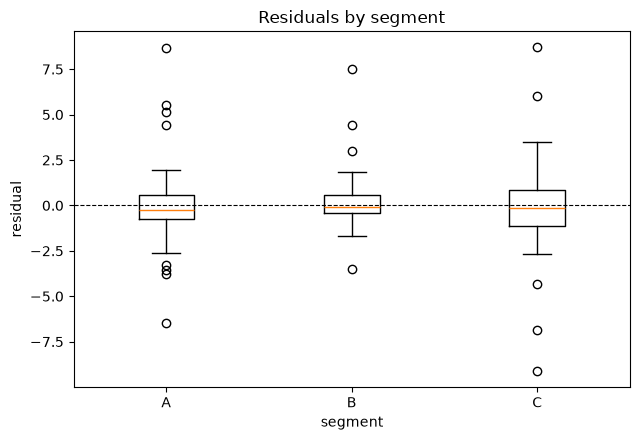

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
grouped = df.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())
ax.boxplot(data)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_xlabel('segment')
ax.set_ylabel('residual')
ax.set_title('Residuals by segment')
fig.tight_layout()
plt.show()

## Bootstrap the metric

The point estimate of MAE is one number; the bootstrap tells us how stable it is. Resampling the
paired (true, predicted) values 600 times gives a 95% interval for MAE itself.

In [13]:
bm = bootstrap_metric(y, y_hat, mae, n_boot=600)
print(f"MAE = {bm['mean']:.4f}   95% CI = [{bm['lo']:.4f}, {bm['hi']:.4f}]")

MAE = 1.2714   95% CI = [1.0551, 1.5310]


## Stakeholder summary

**What we modeled.** One predictor (`x_feature`) explains a continuous outcome (`y_target`). The fitted
slope is ≈2.13, essentially the true value of 2.1, and this holds across every scenario we tried — the
model recovers the relationship reliably.

**Key assumptions.** (1) The relationship is linear — the residuals show no systematic curvature.
(2) The errors are symmetric but **not normal**: they are fat-tailed, so large errors happen more often
than a normal model expects (|residual|>3σ in ~3.3% of rows vs ~0.3% for normal). (3) The 5% missingness
in `x_feature` is missing at random.

**Sensitivity results.** Mean imputation, median imputation, and dropping missing rows all give the same
slope (≈2.13) — the imputation choice changes the *reported error*, not the *fitted relationship*.
Dropping looks better (MAE 1.06 vs 1.28) only because it scores the 171 complete rows and skips the 9
rows that imputation struggles with (those 9 rows alone have MAE ≈5.2). On the shared 171 rows, all three
agree (MAE ≈1.06–1.07).

**Uncertainty.** The bootstrap 95% CI for MAE is [1.06, 1.53]. The Gaussian prediction band is narrower
than the bootstrap band because it assumes normal errors; with fat tails, trust the bootstrap.

**Prediction holds if…** the linear relationship and the heavy-tailed, roughly constant-variance error
structure continue. **The model is sensitive to…** extreme tail events (a few large errors dominate
MAE/RMSE) and to missingness growing above ~5% (imputed rows are the hardest to predict). **Subgroup
risk:** segment C shows a wider residual spread (std 2.8 vs 1.8) — but segments were assigned randomly,
so this is most likely heavy-tail noise in a small subgroup (n=45), not a real effect; monitor, don't act
on it yet.

**Next steps.** Use MAE (or a robust/Huber loss) rather than RMSE to de-emphasize the tails; use
bootstrap CIs for inference; and gather more data before drawing any segment-level conclusions.